1. Setup and Imports

In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

2. Foundations



In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [5]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [6]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(self, grid, start, goal):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self):
        return self.start

    def is_goal(self, state):
        return state == self.goal

    def in_bounds(self, state):
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state):
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state):
        legal_actions = []
        row, col = state
        for action, (dr, dc) in MOVES.items():
            neighbour = (row + dr, col + dc)
            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)
        return legal_actions

    def result(self, state, action):
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(self, state, action, next_state):
        return 1


class SearchAlgorithm(ABC):
    def expand(self, problem, node):
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem):
        pass


3. Weighted Terrain: WeightedGridProblem

In [7]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(self, state: Tuple[int, int], action: str, next_state: Tuple[int, int],) -> float:
      row, col = next_state
      return self.terrain_costs[row][col]

3.1 Self-Check for WeightedGridProblem

In [8]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


4. Heuristic Functions

4.1 Admissibility and Consistency on Our Grid

In [9]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    r1, c1 = state
    r2, c2 = goal
    return abs(r1 - r2) + abs(c1 - c2)

def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    return math.dist(state, goal)


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

4.2 Self-Check for the Heuristics

In [10]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


5. The Priority-Queue Frontier (Provided)

In [11]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

6. The BestFirstSearch Framework

In [12]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
      node = Node(problem.initial_state())
      frontier = PriorityQueue()
      frontier.push(self.evaluation(node, problem), node)
      reached = {node.state: node}
      nodes_expanded = 0
      max_frontier_size = 1

      while frontier:
        node = frontier.pop()

        if problem.is_goal(node.state):
            return SearchResult(algorithm=self.algorithm_name, status="success", solution=node,
                                nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size, reached_count=len(reached))

        nodes_expanded += 1

        for child in self.expand(problem, node):
            s = child.state
            if s not in reached or child.path_cost < reached[s].path_cost:
                reached[s] = child
                frontier.push(self.evaluation(child, problem), child)

        max_frontier_size = max(max_frontier_size, len(frontier))

      return SearchResult(algorithm=self.algorithm_name, status="failure", solution=None,
                        nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size, reached_count=len(reached))

7. Greedy Best-First Search

In [13]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        return self.h(node, problem)

8. A* Search

In [14]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost + self.h(node, problem)

9. Uniform-Cost Search as a Special Case (Provided)

In [15]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

10. Weighted A* Search

In [16]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost + self.weight * self.h(node, problem)

10.1 Self-Check for the Algorithms

In [17]:
test_problem = GridProblem([[0,0,0],[1,1,0],[0,0,0]], start=(0,0), goal=(2,2))
g = GreedyBestFirstSearch(manhattan_distance)
res = g.search(test_problem)
print("Status:", res.status)
print("Nodes expanded:", res.nodes_expanded)
print("Reached:", res.reached_count)
print("Path:", res.path)

Status: success
Nodes expanded: 4
Reached: 5
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2)]


In [18]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


11. Run the Algorithms on the Part A Sample Map

In [19]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,52,5,56
1,A*,success,18,18,18,5,23
2,Weighted A* (W=2),success,18,18,18,5,23
3,Greedy,success,18,18,18,5,23


In [20]:
def plot_path(
    grid,
    start=None,
    goal=None,
    path=None,
    terrain_costs=None,
    title="Grid Map",
):
    arr = np.array(grid)
    height, width = arr.shape
    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)
            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row), 1, 1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5, row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center", va="center", fontsize=8,
                )

    plt.show()

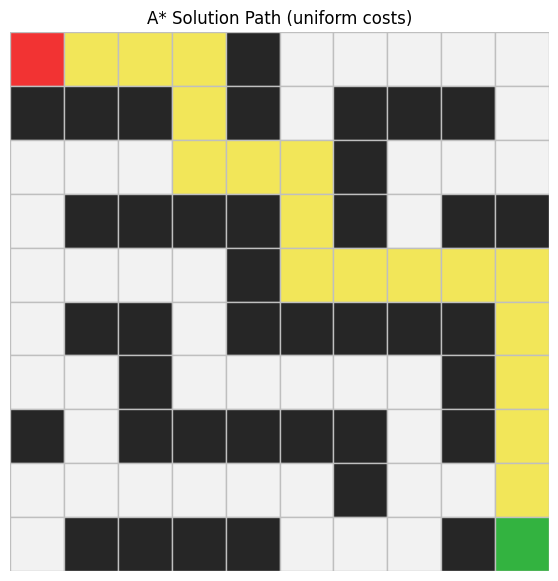

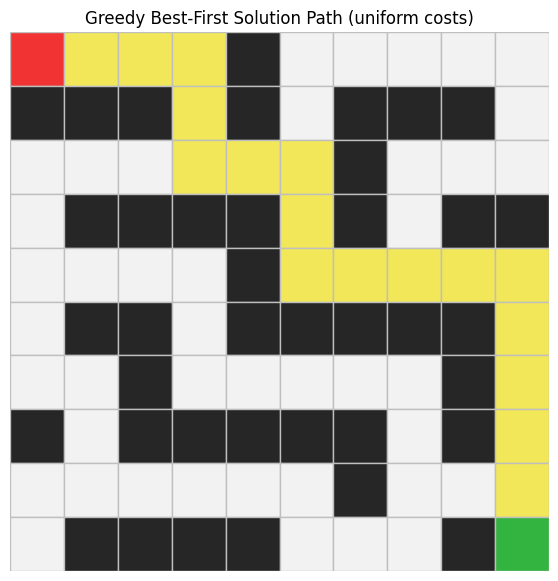

In [21]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

12. The Turbulence Map: Where Greedy Goes Wrong

In [22]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


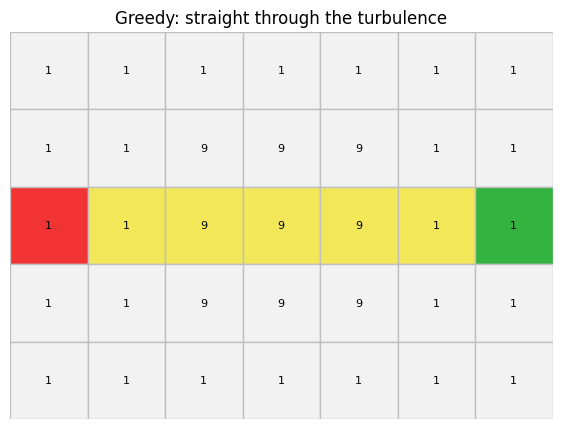

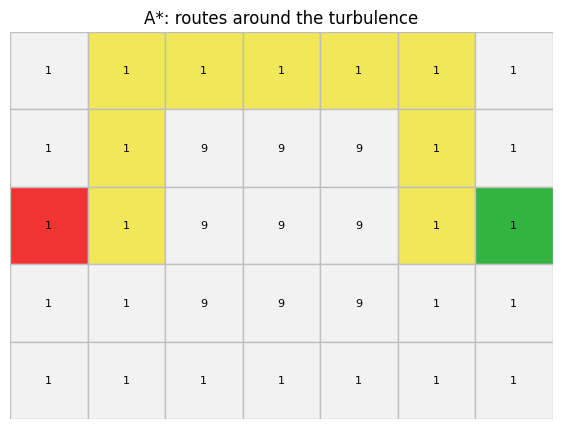

In [23]:

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

13. Experiment: Breaking Admissibility

In [24]:
def inflated_heuristic(factor: float):
    def h(state, goal):
      return factor * manhattan_distance(state, goal)
    return h

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


14. Bonus (Optional): Iterative-Deepening A* (IDA*)

In [25]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def search(self, problem, max_iterations=200):
        metrics = {"nodes_expanded": 0, "max_depth": 0}
        iteration_log = []

        initial_node = Node(problem.initial_state())
        limit = self.heuristic(initial_node.state, problem.goal)

        for _ in range(max_iterations):
            result, next_limit = self._f_limited_search(problem, initial_node, limit, metrics)

            if result is not None:
                return SearchResult(
                    algorithm=self.algorithm_name, status="success", solution=result,
                    nodes_expanded=metrics["nodes_expanded"], max_frontier_size=metrics["max_depth"],
                    iterations=iteration_log,
                )

            iteration_log.append({"limit": limit, "next_limit": next_limit})

            if next_limit == float("inf"):
                return SearchResult(
                    algorithm=self.algorithm_name, status="failure", solution=None,
                    nodes_expanded=metrics["nodes_expanded"], max_frontier_size=metrics["max_depth"],
                    iterations=iteration_log,
                )

            limit = next_limit

        return SearchResult(
            algorithm=self.algorithm_name, status="cutoff", solution=None,
            nodes_expanded=metrics["nodes_expanded"], max_frontier_size=metrics["max_depth"],
            iterations=iteration_log,
        )

    def _f_limited_search(self, problem, node, limit, metrics):
        f = node.path_cost + self.heuristic(node.state, problem.goal)

        if f > limit:
            return None, f

        if problem.is_goal(node.state):
            return node, f

        metrics["nodes_expanded"] += 1
        metrics["max_depth"] = max(metrics["max_depth"], node.depth)
        next_limit = float("inf")

        for child in self.expand(problem, node):
            ancestor = node
            on_path = False
            while ancestor is not None:
                if ancestor.state == child.state:
                    on_path = True
                    break
                ancestor = ancestor.parent
            if on_path:
                continue

            result, new_f = self._f_limited_search(problem, child, limit, metrics)
            if result is not None:
                return result, new_f
            next_limit = min(next_limit, new_f)

        return None, next_limit

ida = IDAStarSearch(manhattan_distance)
show_results([astar.search(uniform_problem), ida.search(uniform_problem)])

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A*,success,18,18,18,5,23
1,IDA*,success,18,18,18,17,0


15. Create Your Own Maps

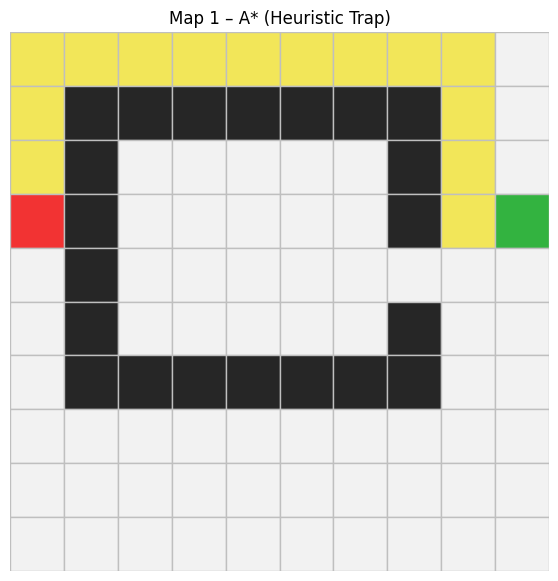

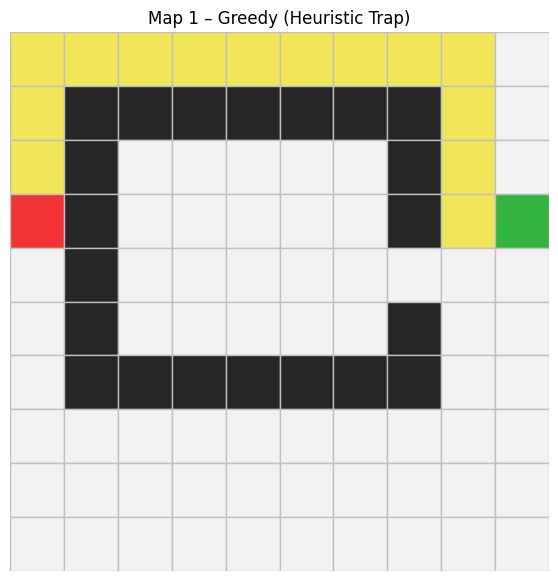

In [30]:
custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
]

custom_costs_1 = [
    [1]*10,
    [1]*10,
    [1]*10,
    [1]*10,
    [1]*10,
    [1]*10,
    [1]*10,
    [1]*10,
    [1]*10,
    [1]*10,
]

custom_start_1 = (3, 0)
custom_goal_1 = (3, 9)

custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
)
custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]
show_results(custom_results_1)

plot_path(custom_grid_1, custom_start_1, custom_goal_1,
          path=custom_results_1[1].path, title="Map 1 – A* (Heuristic Trap)")
plot_path(custom_grid_1, custom_start_1, custom_goal_1,
          path=custom_results_1[3].path, title="Map 1 – Greedy (Heuristic Trap)")

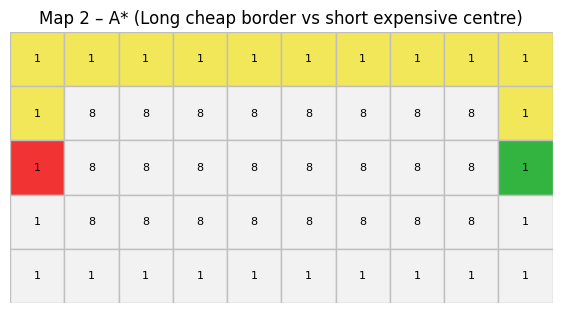

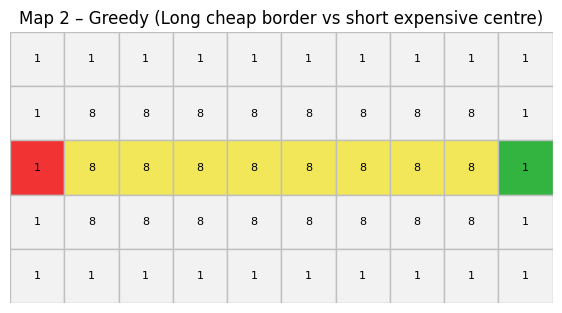

In [27]:
custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

custom_costs_2 = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 8, 8, 8, 8, 8, 8, 8, 8, 1],
    [1, 8, 8, 8, 8, 8, 8, 8, 8, 1],
    [1, 8, 8, 8, 8, 8, 8, 8, 8, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 8, 8, 8, 8, 8, 8, 8, 8, 1],
    [1, 8, 8, 8, 8, 8, 8, 8, 8, 1],
    [1, 8, 8, 8, 8, 8, 8, 8, 8, 1]]

custom_start_2 = (2, 0)
custom_goal_2 = (2, 9)

custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)
custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]
show_results(custom_results_2)

plot_path(custom_grid_2, custom_start_2, custom_goal_2,
          path=custom_results_2[1].path, terrain_costs=custom_costs_2,
          title="Map 2 – A* (Long cheap border vs short expensive centre)")
plot_path(custom_grid_2, custom_start_2, custom_goal_2,
          path=custom_results_2[3].path, terrain_costs=custom_costs_2,
          title="Map 2 – Greedy (Long cheap border vs short expensive centre)")

# 16. Reflection Questions

16.1 Heuristic ***Functions***



1.   H(n) estimates the  total remaining cost from the current node all the way to the goal. The knowledge comes from the drone's GPS.

2.  Restrictions removed:

*   Obstacles since it assumes the drone can fly through any cel
*   real terrain costs and assumes that every move costs 1

3. Manhattan distance dominates Euclidean distance, since Euclidean distance is always ≤ Manhattan distance for the same state/goal pair. Because Manhattan is the more informed heuristic, it gives A* a more accurate estimate of the remaining cost. This predicts that A* will expand fewer nodes when using Manhattan distance compared to Euclidean distance.

4. Requiring all terrain costs to be ≥ 1 keeps Manhattan distance admissible because each move costs at least as much as Manhattan distance assumes so h(n) can never exceed the true cost. If a terrain cost were 0.5, then estimated cost will exceed the true cost.





***16.2 Greedy Best-First Search***



1.   Greedy ignores g(n), the cost already paid to reach the current node. Since h(n) is purely geometric distance and has no knowledge of terrain costs, Greedy has no way to 'feel' that the turbulence cells cost 9 each. It simply chooses whichever move looks closest to the goal in straight-line distance, so it plowed directly through the cost-9 turbulence band, finding a path in only 6 moves but at a total cost of 30

2.   Greedy expanding fewer nodes than A* is not enough to call it better algorithm becaus it is more expensive compared to A*. On the turbulence map, Greedy expanded only 6 nodes but returned a path costing 30, while A* expanded 25 nodes but found the much cheaper path costing 10.  

3. A drone mission where greedy's behavior is acceptable is in case of emergency and the cost doesn't matter. An example is when a drone needs to land as soon as possible before a strom hits. In this case, finding the quickest path is more important than finding the cheapest one.




***16.3 ***A* ***Search***



1.   f(n) = g(n) + h(n) represents the drone's estimated total flight cost which is the sum of the  cost already spent to get to the current state g(n) plus  estimated cost still left to reach the goal h(n).

2.   A* must apply the goal test when a node is popped, not when it is generated, because the first time the goal node is generated might be from an expensive, while a cheaper path to the goal could still be unexplored in the frontier.

      On the turbulence map, if A* tested for the goal early, it could generate the goal via a path straight through the cost-9 turbulence band and stop immediately, reporting that expensive path as the answer; even though a much cheaper detour around the turbulence was still waiting in the frontier.

3. Reached needs to be a dictionary because in part A's BFS, every move cost 1 so the first time a state was reached was guaranteed to the shortest path. But in part B, because A* makes a decision based on the cost, and with non-uniform terrain costs, it needs to compare the costs to choose the cheapest.

4. To find the optimal path, UCS expanded 52 nodes while A* expanded 18 which is the same number as the solution's depth. This gap shows that the Manhattan heuristic eliminates a large amount of unnecessary exploration.

***16.4 Admissibility and Consistency***



1.   Admissible(h(n) ≤ h*(n)): the heuristic never overestimates the true remaining cost

Consistent(h(n) ≤ c(n, a, n') + h(n')): for every move, the heuristic satisfies inequality that the estimate at a node can't be more than the actual step cost plus the estimate at the next node.

consistent imply admissible. Every consistent heuristic is admissible, but not every admissible heuristic is consistent.

2.   once a heuristic stops being admissible, A* is no longer guaranteed to find the optimal solution

3. Yes, Manhattan distance is consistent on our unit-cost grid. For example, with n = (5, 5) and goal (0, 0): h(n) = |5-0| + |5-0| = 10. Moving UP to n' = (4, 5) costs 1, and h(n') = |4-0| + |5-0| = 9. Checking the inequality: 10 ≤ 10 which is true.

This works because every move on a 4-connected grid changes exactly one coordinate by 1, so Manhattan distance can change by at most 1 per move which matches exactly the move's cost of 1. So the change in h never exceeds the move cost, and the triangle inequality is always true.



***16.5 Weighted A* and Trade-offs ***



1.   W = 0: f(n) = g(n) + 0·h(n) = g(n), so the search relies purely on cost-so-far, becoming UCS.

     As W = 1: f(n) = g(n) + h(n), balancing the cost already spent (g(n)) with the estimated cost remaining (h(n)), giving A* search.
  
     W → ∞: the term W·h(n) becomes so large that g(n) becomes negligible, so the search is driven almost entirely by the heuristic giving Greedy Best-First Search.

2.   With W=2, the bound guarantees the solution cost will be no more than 2x the true optimal cost; it allows for some suboptimality, but limits how bad it can get.

     In my experiments, Weighted A* returned the exact optimal cost (18 and 10) on both maps which is far inside the worst-case bound of 36 and 20. This shows that the suboptimality bound is a guaranteed safety net, not a typical outcome.

3. I would choose weighted A* because A*  computes more nodes making it slow which would risk running out of the 90-second margin, and even though Greedy is fast, it does not guarantee the optimal solution, so the choosen path might be expensive that it uses more battery. Weighted A* solves both issues.





***16.6 Memory and Real-World Drone Context***



1.  A* is memory-hungry because of frontier and reached which grow exponentially with the depth of the search since A* never discards anything.

     IDA* avoids this by using recursive depth-first search instead of a frontier and a reached dictionary. It only ever keeps the nodes on the single current path in memory, so its memory use grows only linearly not exponentially.

     The cost IDA* pays instead is repeated re-expansion of nodes. Because it doesn't remember which states it has already explored since it doesn't have reached dictionary.

2.  

*   Weather: include wind speed since flying against strong wind is more costly.
*   Drone's current battery state
*   Signal strength and communication range: weak signal can lead to high cost.

3. If the goal moves, the heuristic h(n), which is computed using the goal's coordinates, becomes outdated the moment the goal shifts and the search would be optimizing toward a position the target is no longer at.

4.  I would ship A* with Manhattan distance as the default algorithm, since it guarantees the optimal path while expanding far fewer nodes, making it reliable and efficient, than other uninformed searches.

If the flight computer has very limited memory, I would switch to IDA*.

If the the mission is time_critical, I wouls switch to weighted A*.





